# 1. 확률분포의 추정

### 확률분포의 결정

#### 연습 문제 9.1.1
다음 코드로 사이킷런 패키지가 제공하는 보스턴 집값 데이터를 살펴보고 각각의 데이터의 확률분포 특성을 설명하라. 각 데이터에 적합한 확률분포가 존재한다면 어떤 확률분포인지도 설명하라.

In [1]:
from sklearn.datasets import load_boston
boston = load_boston()
dfX = pd.DataFrame(boston.data, columns=boston.feature_names)
dfy = pd.DataFrame(boston.target, columns=["MEDV"])
df = pd.concat([dfX, dfy], axis=1)

In [2]:
df.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0.0,0.573,6.030,80.8,2.5050,1.0,273.0,21.0,396.90,7.88,11.9


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [4]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### 모멘트 방법

다음과 같은 표본 데이터가 주어졌을 때,  
(1) 표본 데이터의 분포를 시각화하라.  
(2) 모멘트 방법을 통해 이론적 모멘트를 추정하라

In [5]:
# 주어진 자료
df = pd.DataFrame({'produce':[7, 8, 10, 11, 12, 14], 'days':[10, 10, 20, 30, 20, 10]})
df

,produce,days
0,7,10
1,8,10
2,10,20
3,11,30
4,12,20
5,14,10


In [6]:
# 확률로 변환
df['probs'] = df.days/df.days.sum()
df

,produce,days,probs
0,7,10,0.1
1,8,10,0.1
2,10,20,0.2
3,11,30,0.3
4,12,20,0.2
5,14,10,0.1


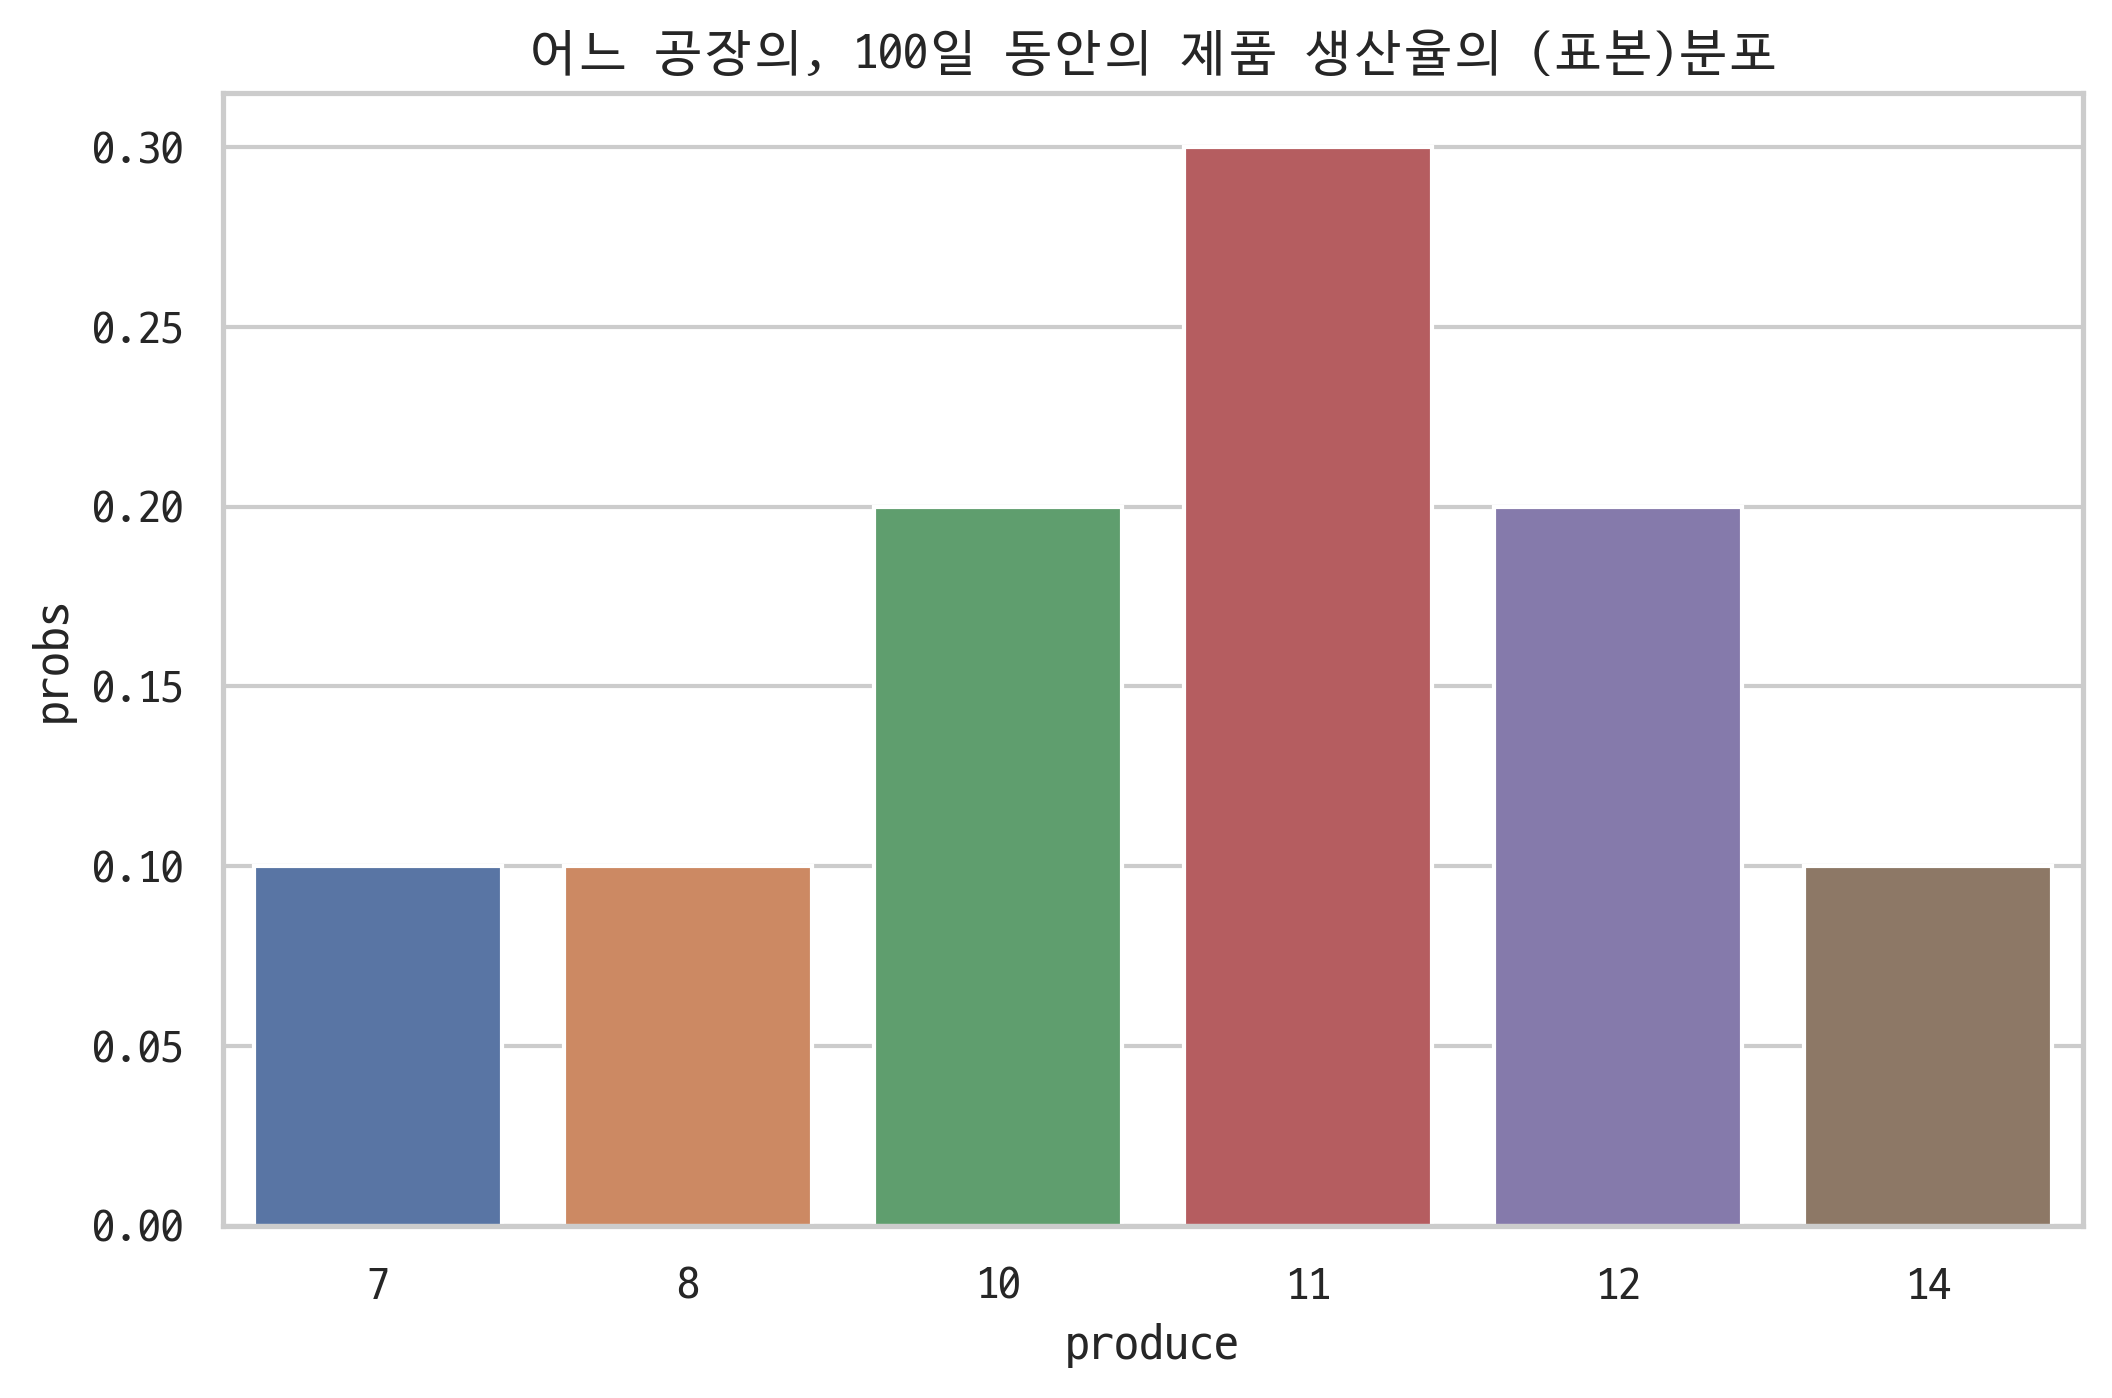

In [7]:
# 표본 데이터 시각화
sns.barplot(x='produce', y='probs', data=df)
plt.title('어느 공장의, 100일 동안의 제품 생산율의 (표본)분포')
plt.show()

위의 표본 데이터는 어떤 분포에서 나온 데이터일까?  
답 = 이항분포

But why?
- 문제에 대한 해석이 불완전했어

In [8]:
# np.sum((df.produce * df.days - mean) ** 2) / (df.days.sum() - 1) 

NameError: name 'mean' is not defined

In [9]:
# 모멘트 방법으로 모수 추정 - 표본의 모멘트가 모수의 모멘트라고 가정
# 표본평균 = 기댓값
mean = np.sum(df.produce*df.probs)
# 표본분산 = 분산
var = np.sum(((df.produce - mean) ** 2) * df.probs)

In [10]:
print('1차 모멘트 기댓값은 "{}", 2차 모멘트 분산은 "{}"'.format(mean, var))

1차 모멘트 기댓값은 "10.6", 2차 모멘트 분산은 "3.6400000000000006"


In [11]:
# 다른 방법으로 구하기 1 -  좋은 코드
mean = np.average(df.produce, weights=df.probs)
var = np.average((df.produce - mean)**2, weights=df.probs)
print(mean, var)

10.600000000000001 3.64


In [12]:
# 다른 방법으로 구하기 2 - 이론적으로  var는 이게 제일 정확
mean = np.sum(df.produce * df.days) / df.days.sum()
var = np.sum(((df.produce - mean) ** 2) * df.days) / (df.days.sum() - 1)
print(mean, var)

10.6 3.676767676767677


0.653135124833238 16.229413481178874


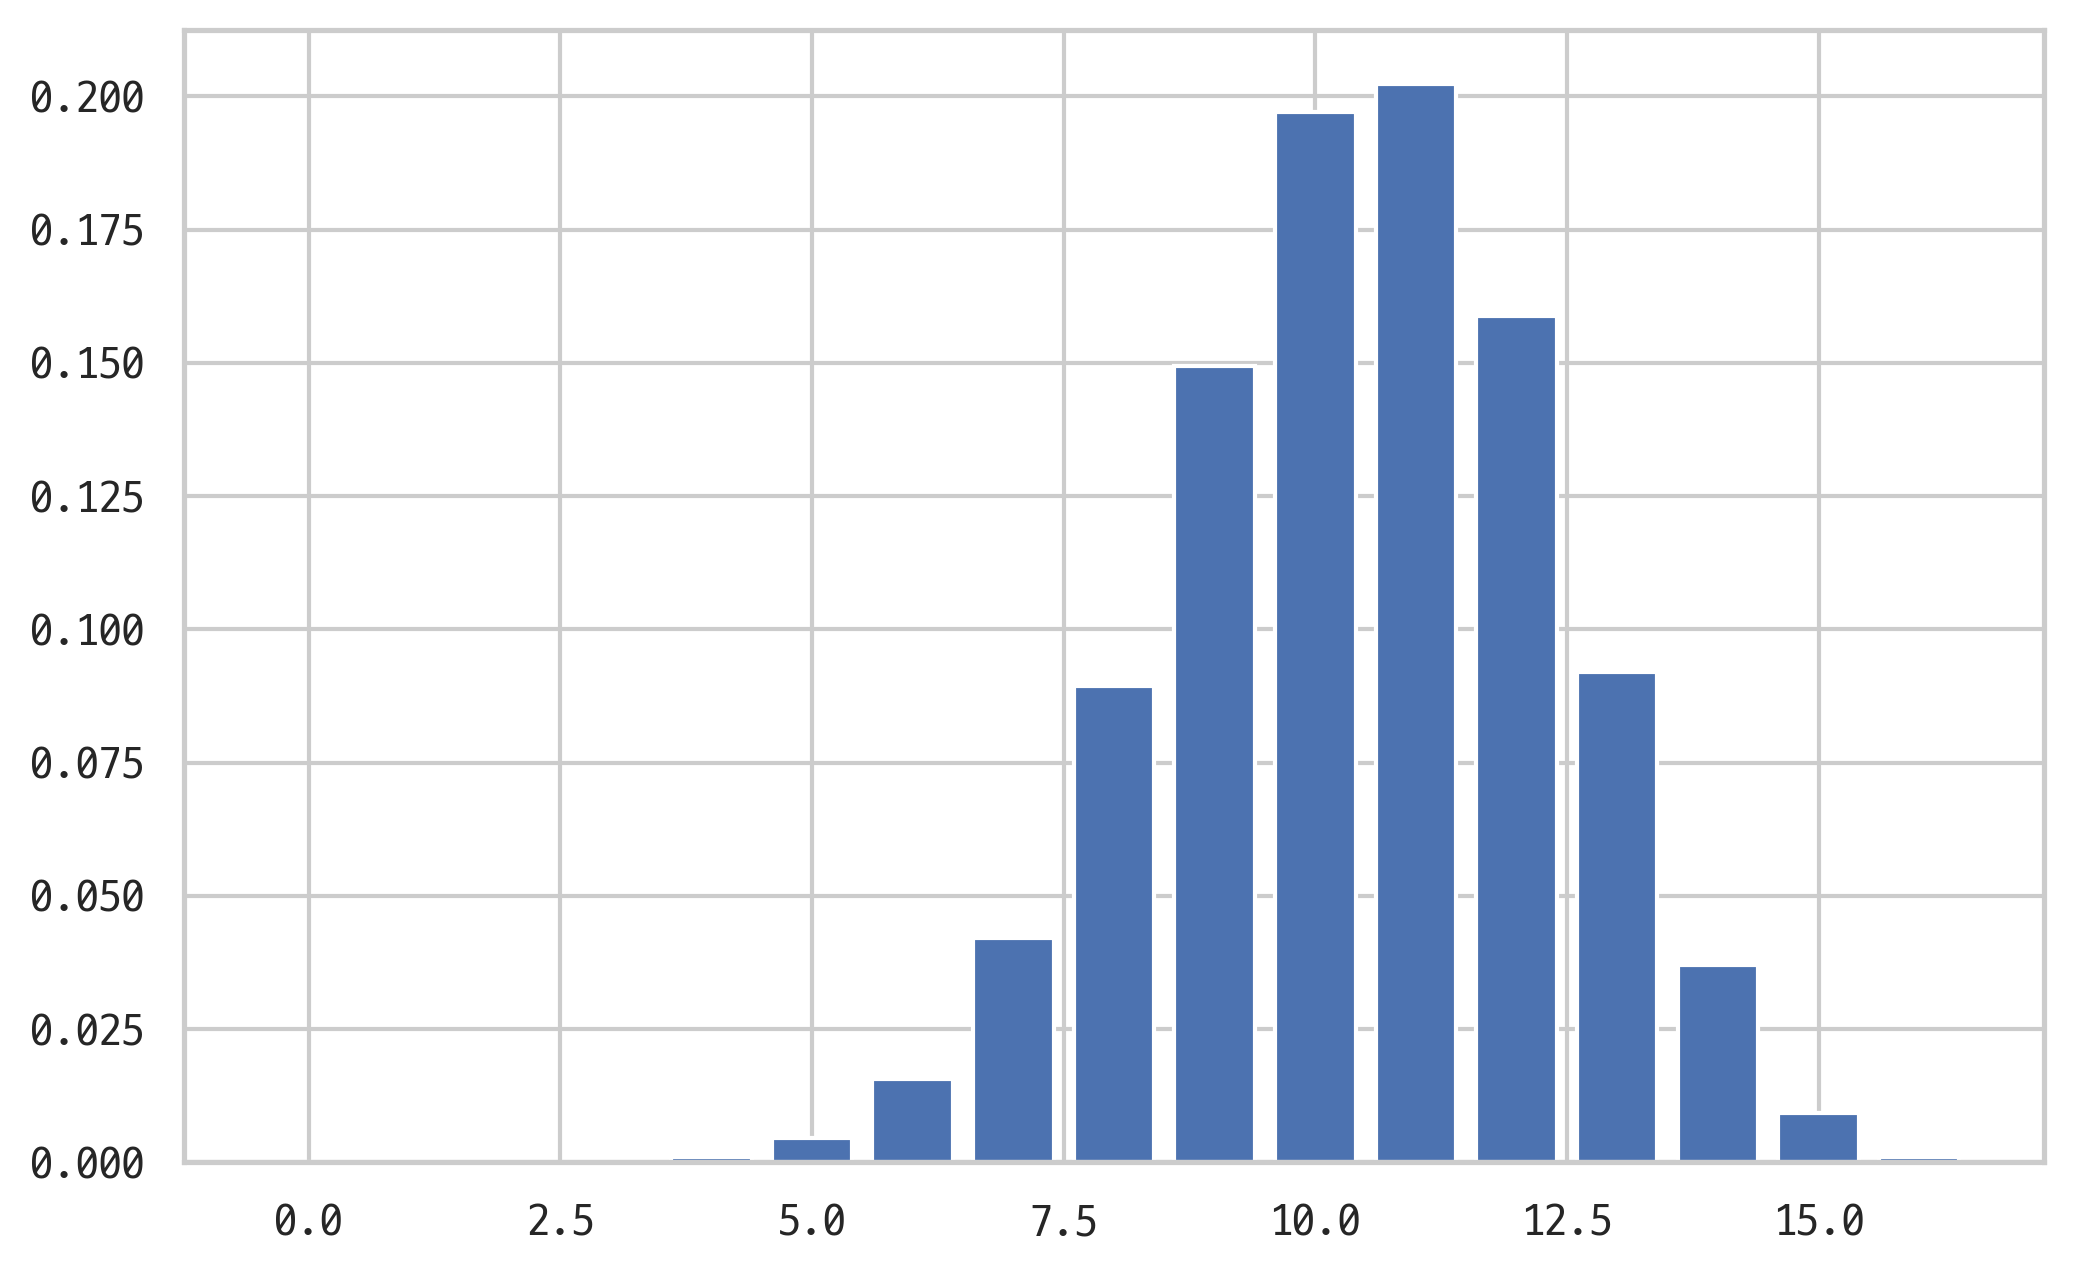

In [13]:
# 해당 모수로 확률질량함수 그려보기
mu = -(var / mean) + 1
N = mean / mu
print(mu, N)

# rv = sp.stats.binom(round(N), mu)
rv = sp.stats.binom(16, mu)
# xx = np.arange(round(N)+1)
xx = np.arange(16+1)
plt.bar(xx, rv.pmf(xx))
plt.show()

In [14]:
# 모멘트로 만든 이론 분포와 표본분포 비교해보기
df2 = pd.DataFrame({'이론':rv.pmf(xx)})

In [15]:
df2.reset_index(inplace=True)

In [16]:
df2.rename(columns={'index':'produce'}, inplace=True)

In [17]:
df_new = pd.merge(df2, df, on='produce', how='left').drop(columns='days').fillna(0)

In [18]:
df_new.rename(columns={'probs':'표본'}, inplace=True)
df_new

,produce,이론,표본
0,0,4.391018e-08,0.0
1,1,1.322903e-06,0.0
2,2,1.868237e-05,0.0
3,3,1.641653e-04,0.0
4,4,1.004633e-03,0.0
5,5,4.540058e-03,0.0
6,6,1.567276e-02,0.0
7,7,4.215899e-02,0.1
8,8,8.930699e-02,0.1
9,9,1.494774e-01,0.0


In [19]:
df_new = df_new.drop(columns='produce').stack().reset_index()
df_new.columns = ['표본값', '유형', '비율']
df_new.pivot('표본값', '유형', '비율')

유형,이론,표본
표본값,,
0,4.391018e-08,0.0
1,1.322903e-06,0.0
2,1.868237e-05,0.0
3,1.641653e-04,0.0
4,1.004633e-03,0.0
5,4.540058e-03,0.0
6,1.567276e-02,0.0
7,4.215899e-02,0.1
8,8.930699e-02,0.1


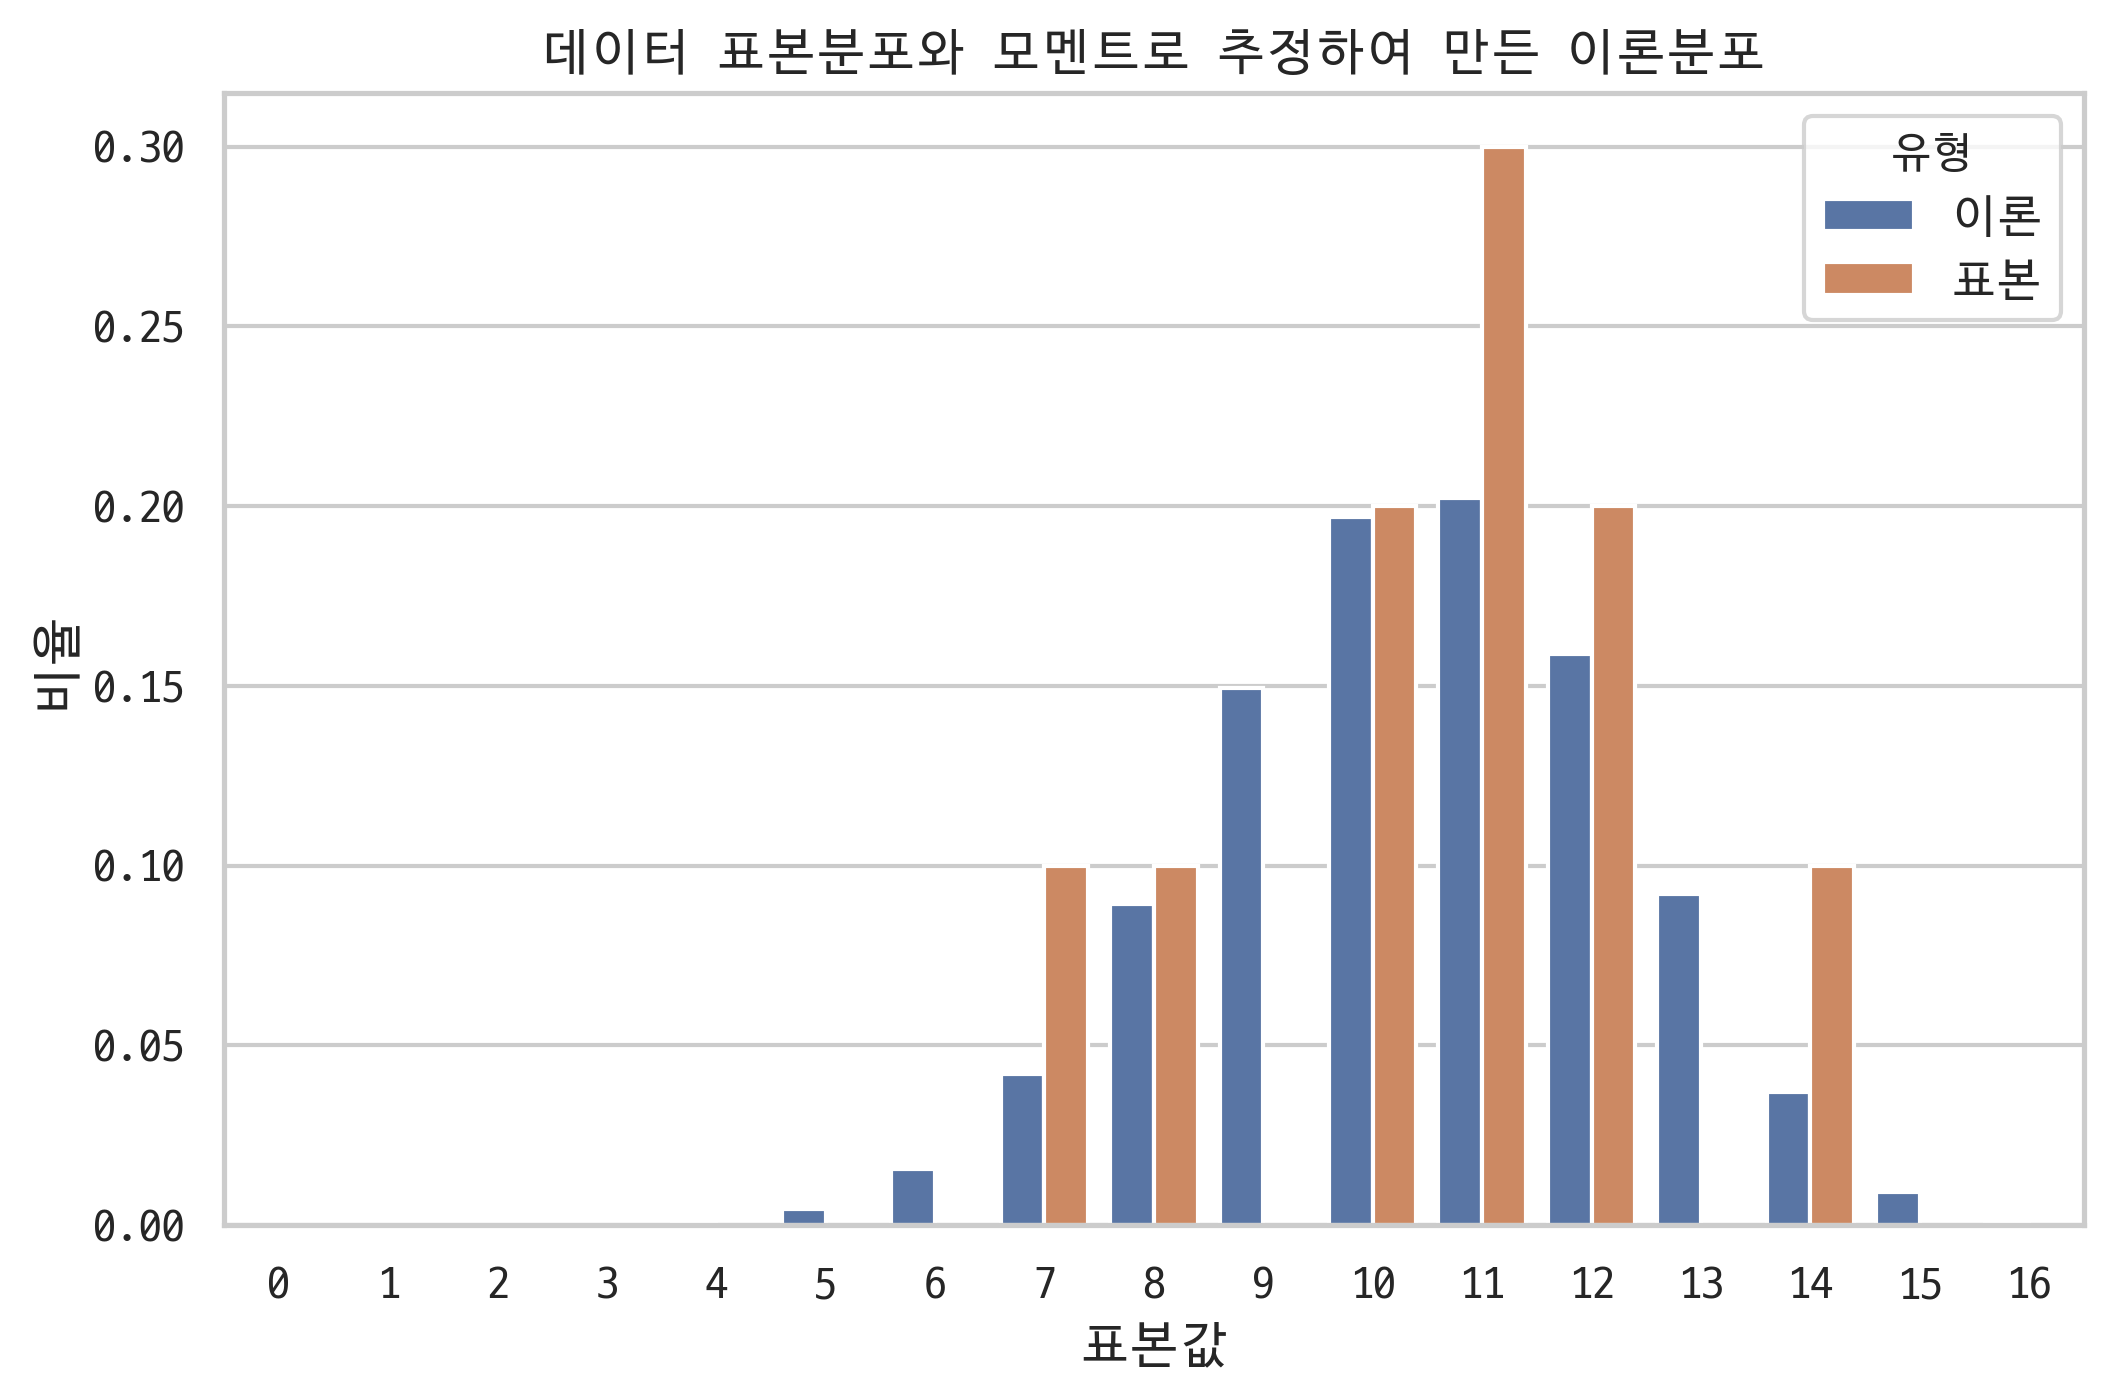

In [20]:
sns.barplot(x='표본값', y='비율', hue='유형', data=df_new)
plt.title('데이터 표본분포와 모멘트로 추정하여 만든 이론분포')
plt.show()

#### 연습 문제 9.1.2
위 연습 문제에서 나온 보스턴 집값 데이터 각각에 대해 seaborn의 `distplot()` 함수로 히스토그램을 그려라. 그리고 `distplot()` 함수의 모수 추정 기능을 사용하여 각각의 데이터에 적합한 확률분포의 확률밀도함수를 그려라. (범주형 데이터는 제외한다.)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


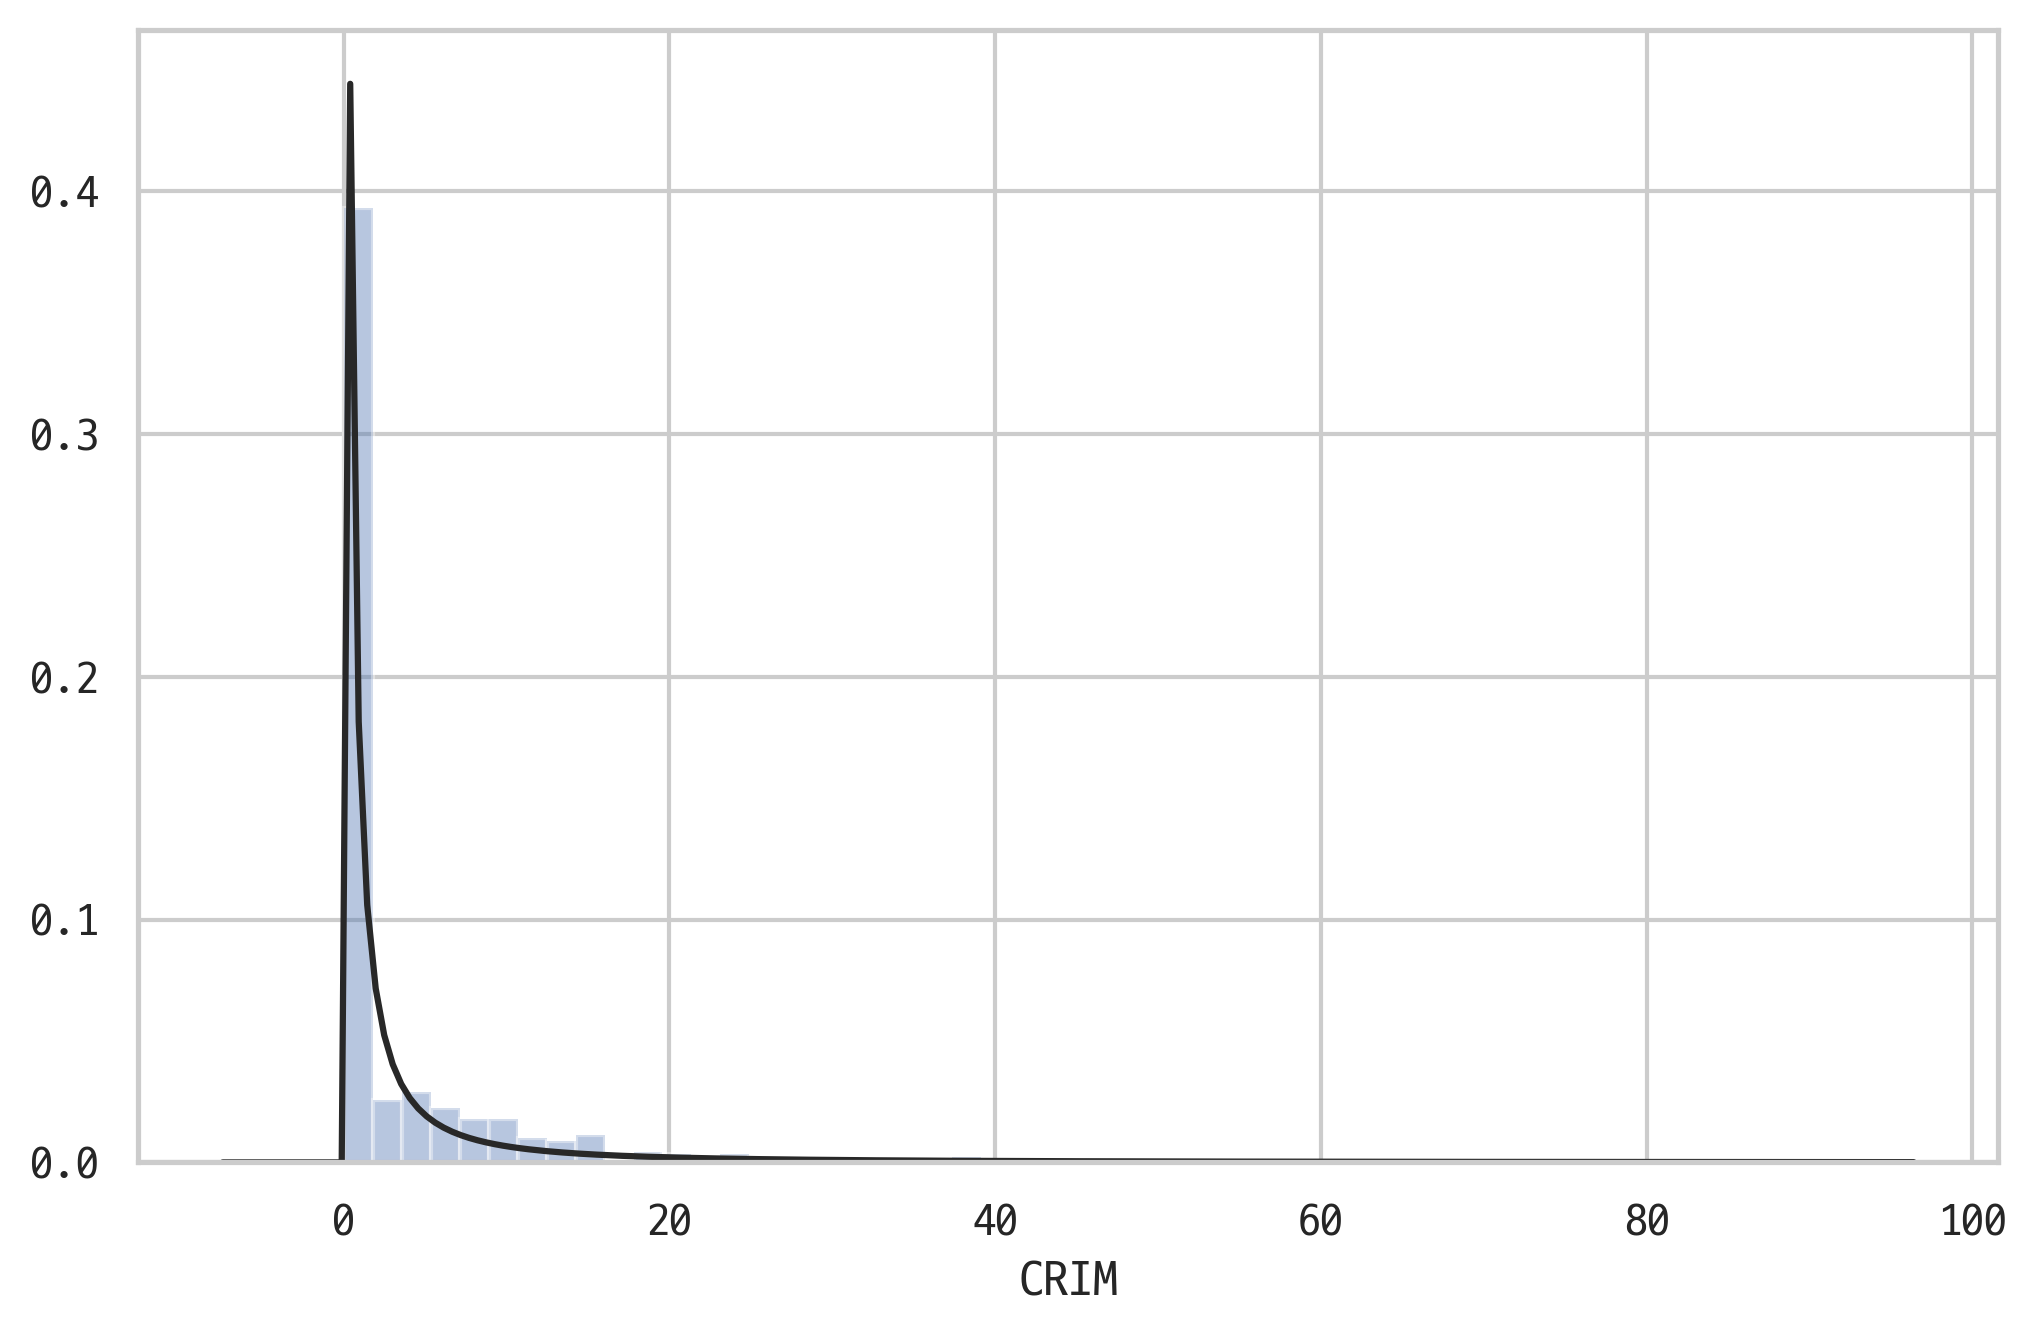

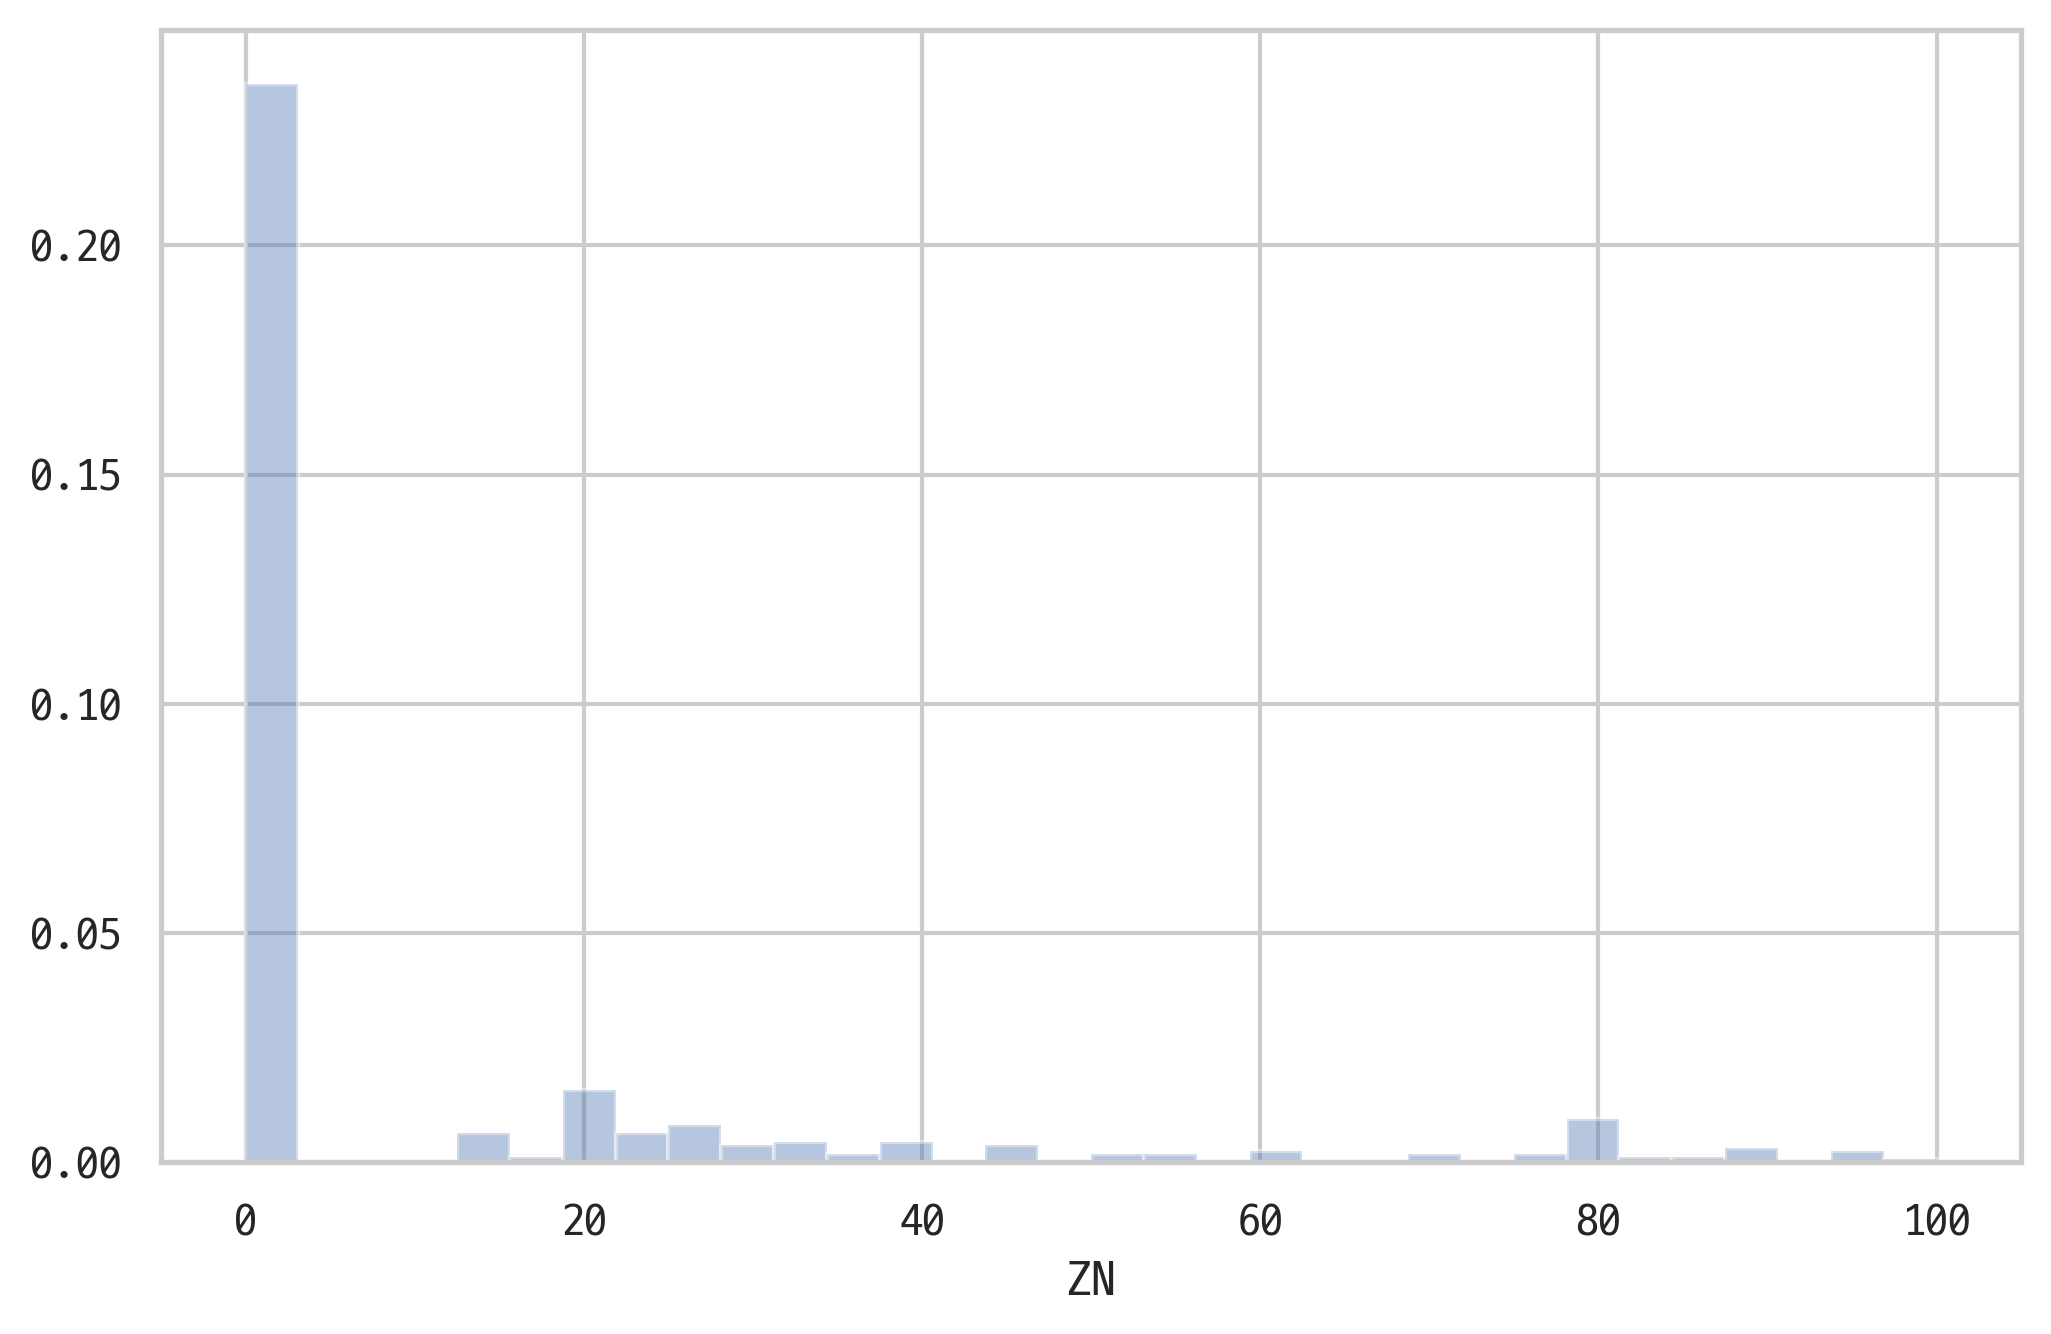

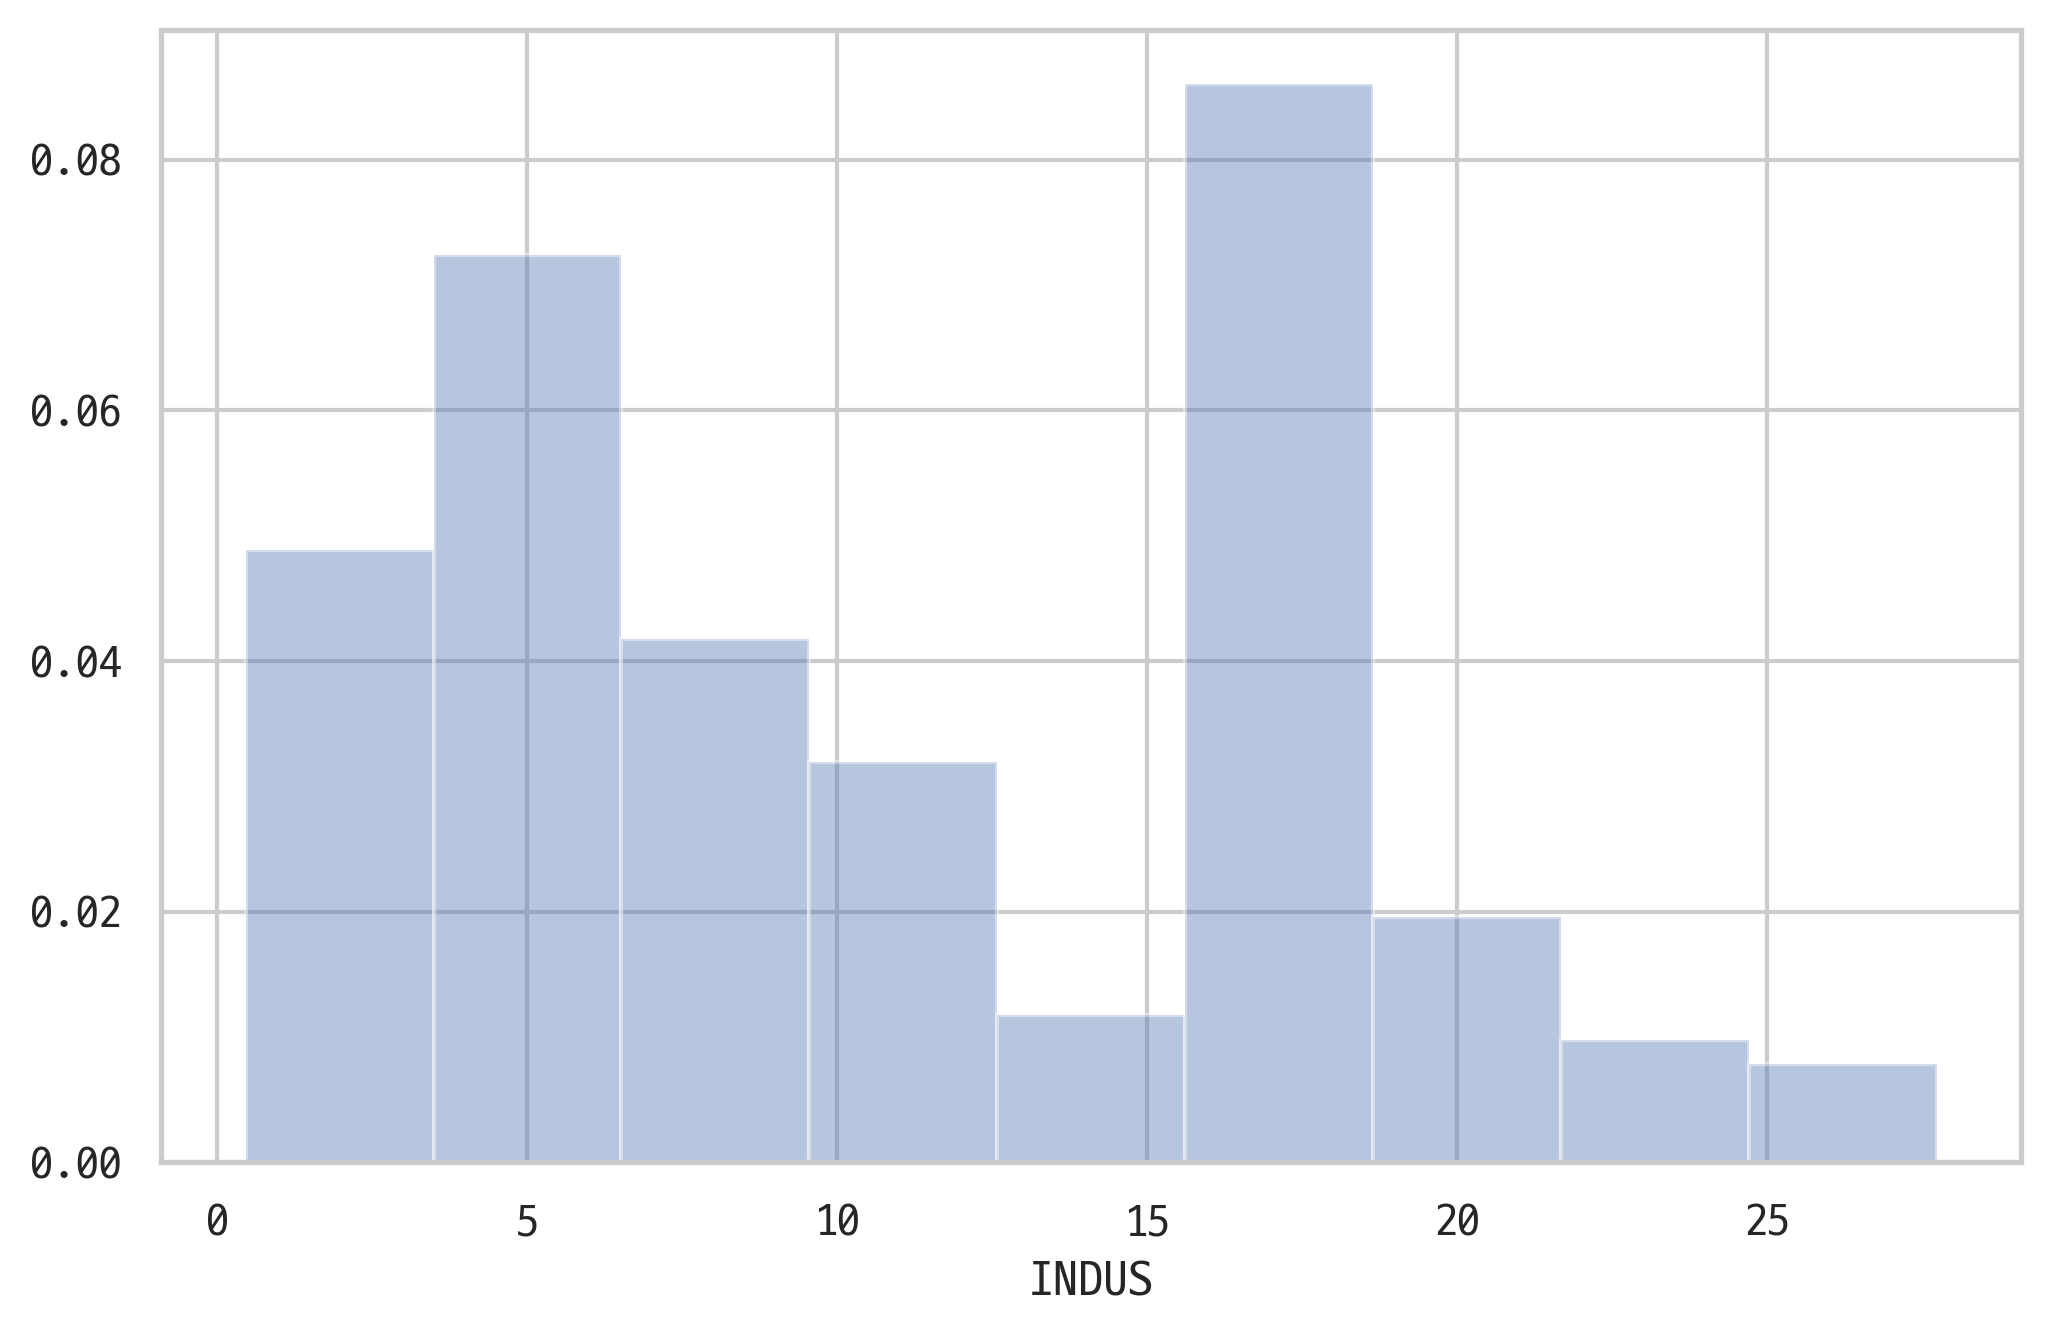

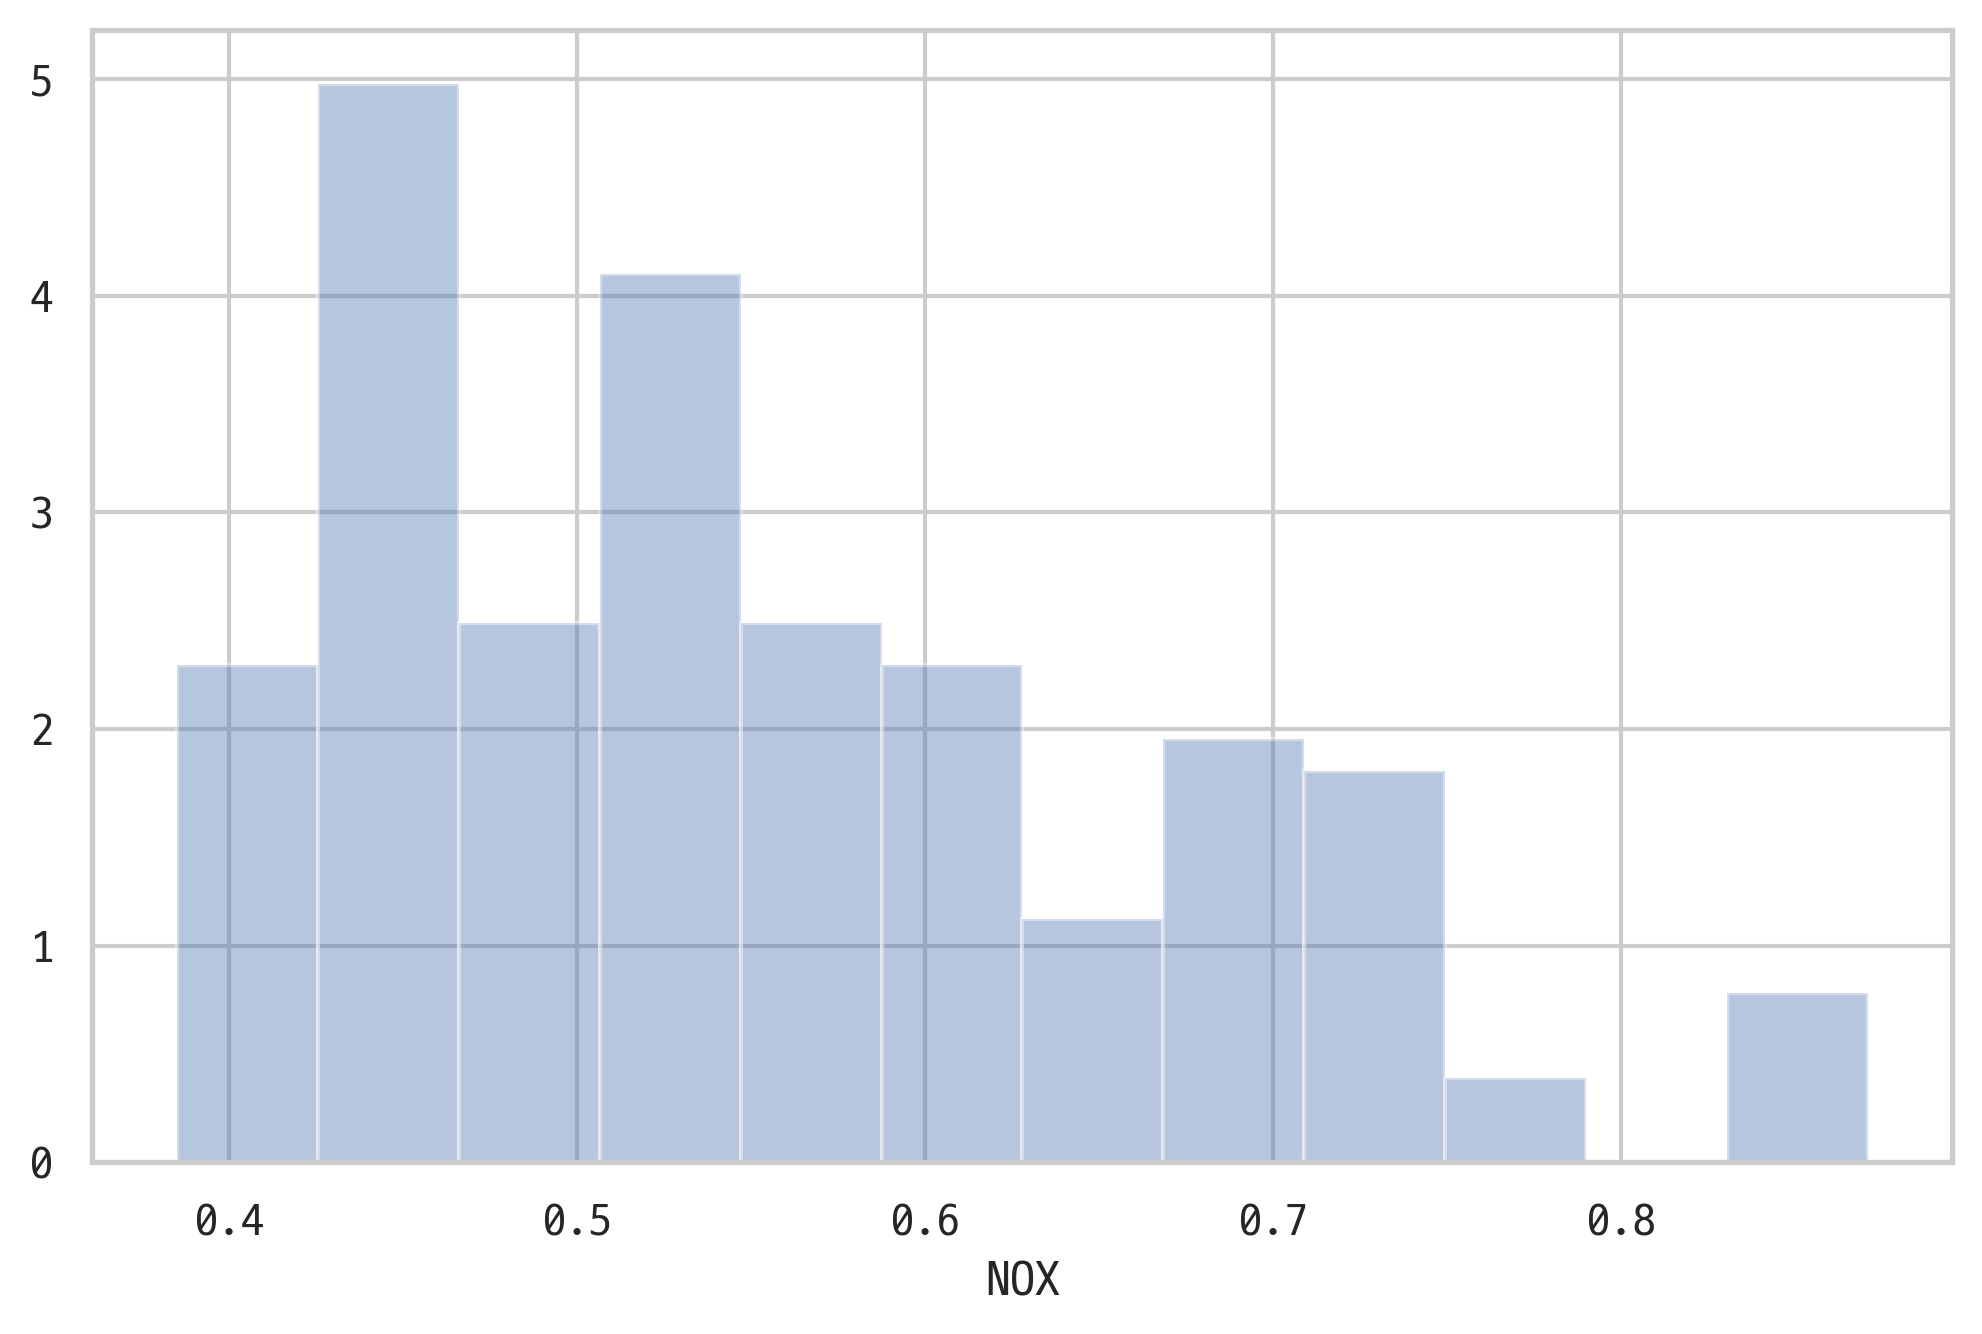

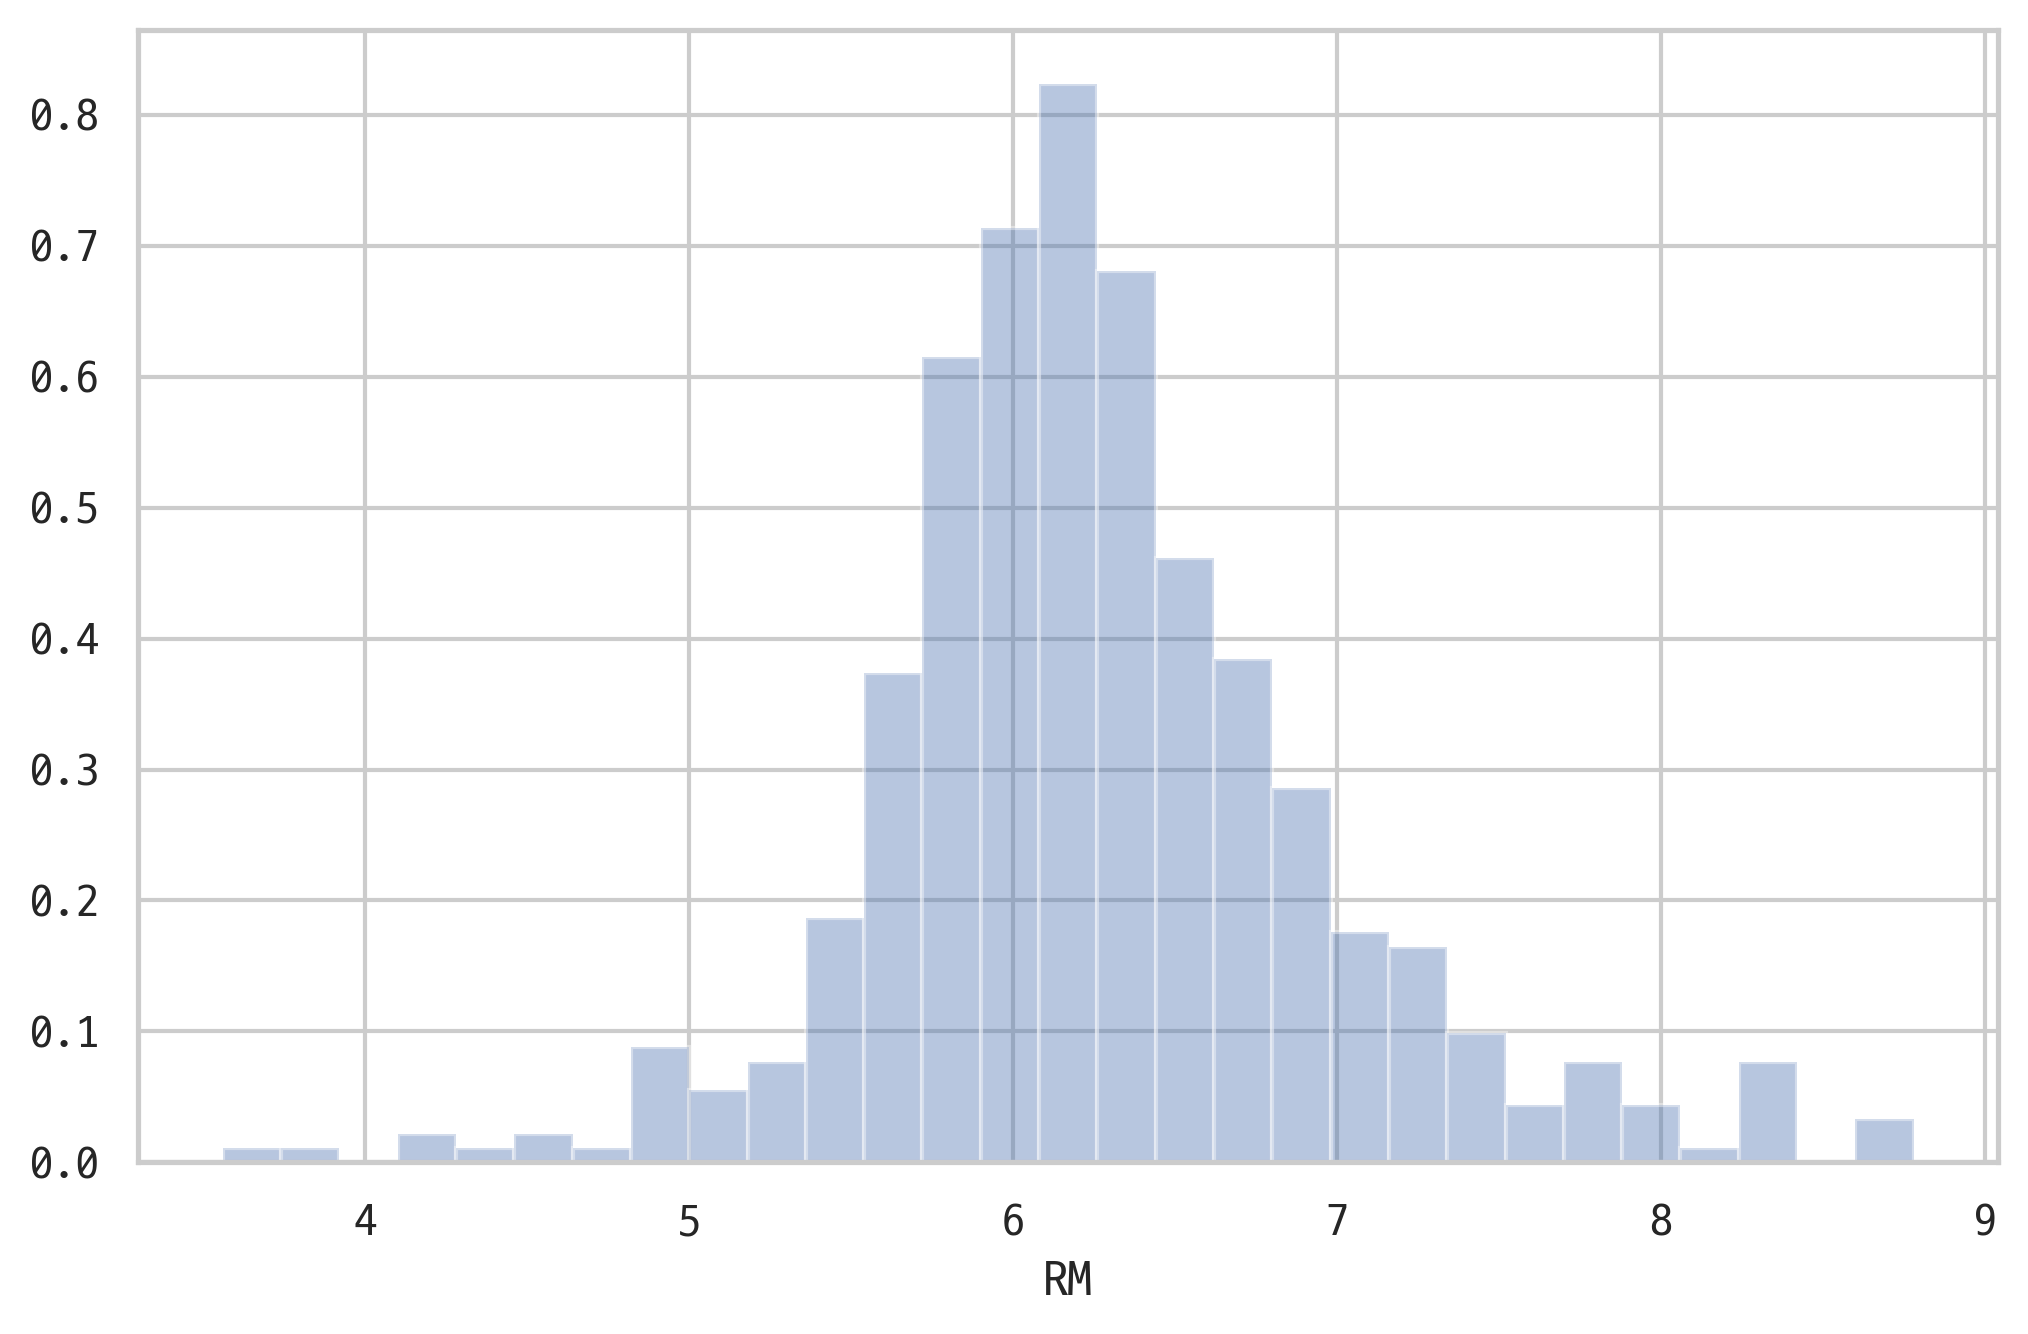

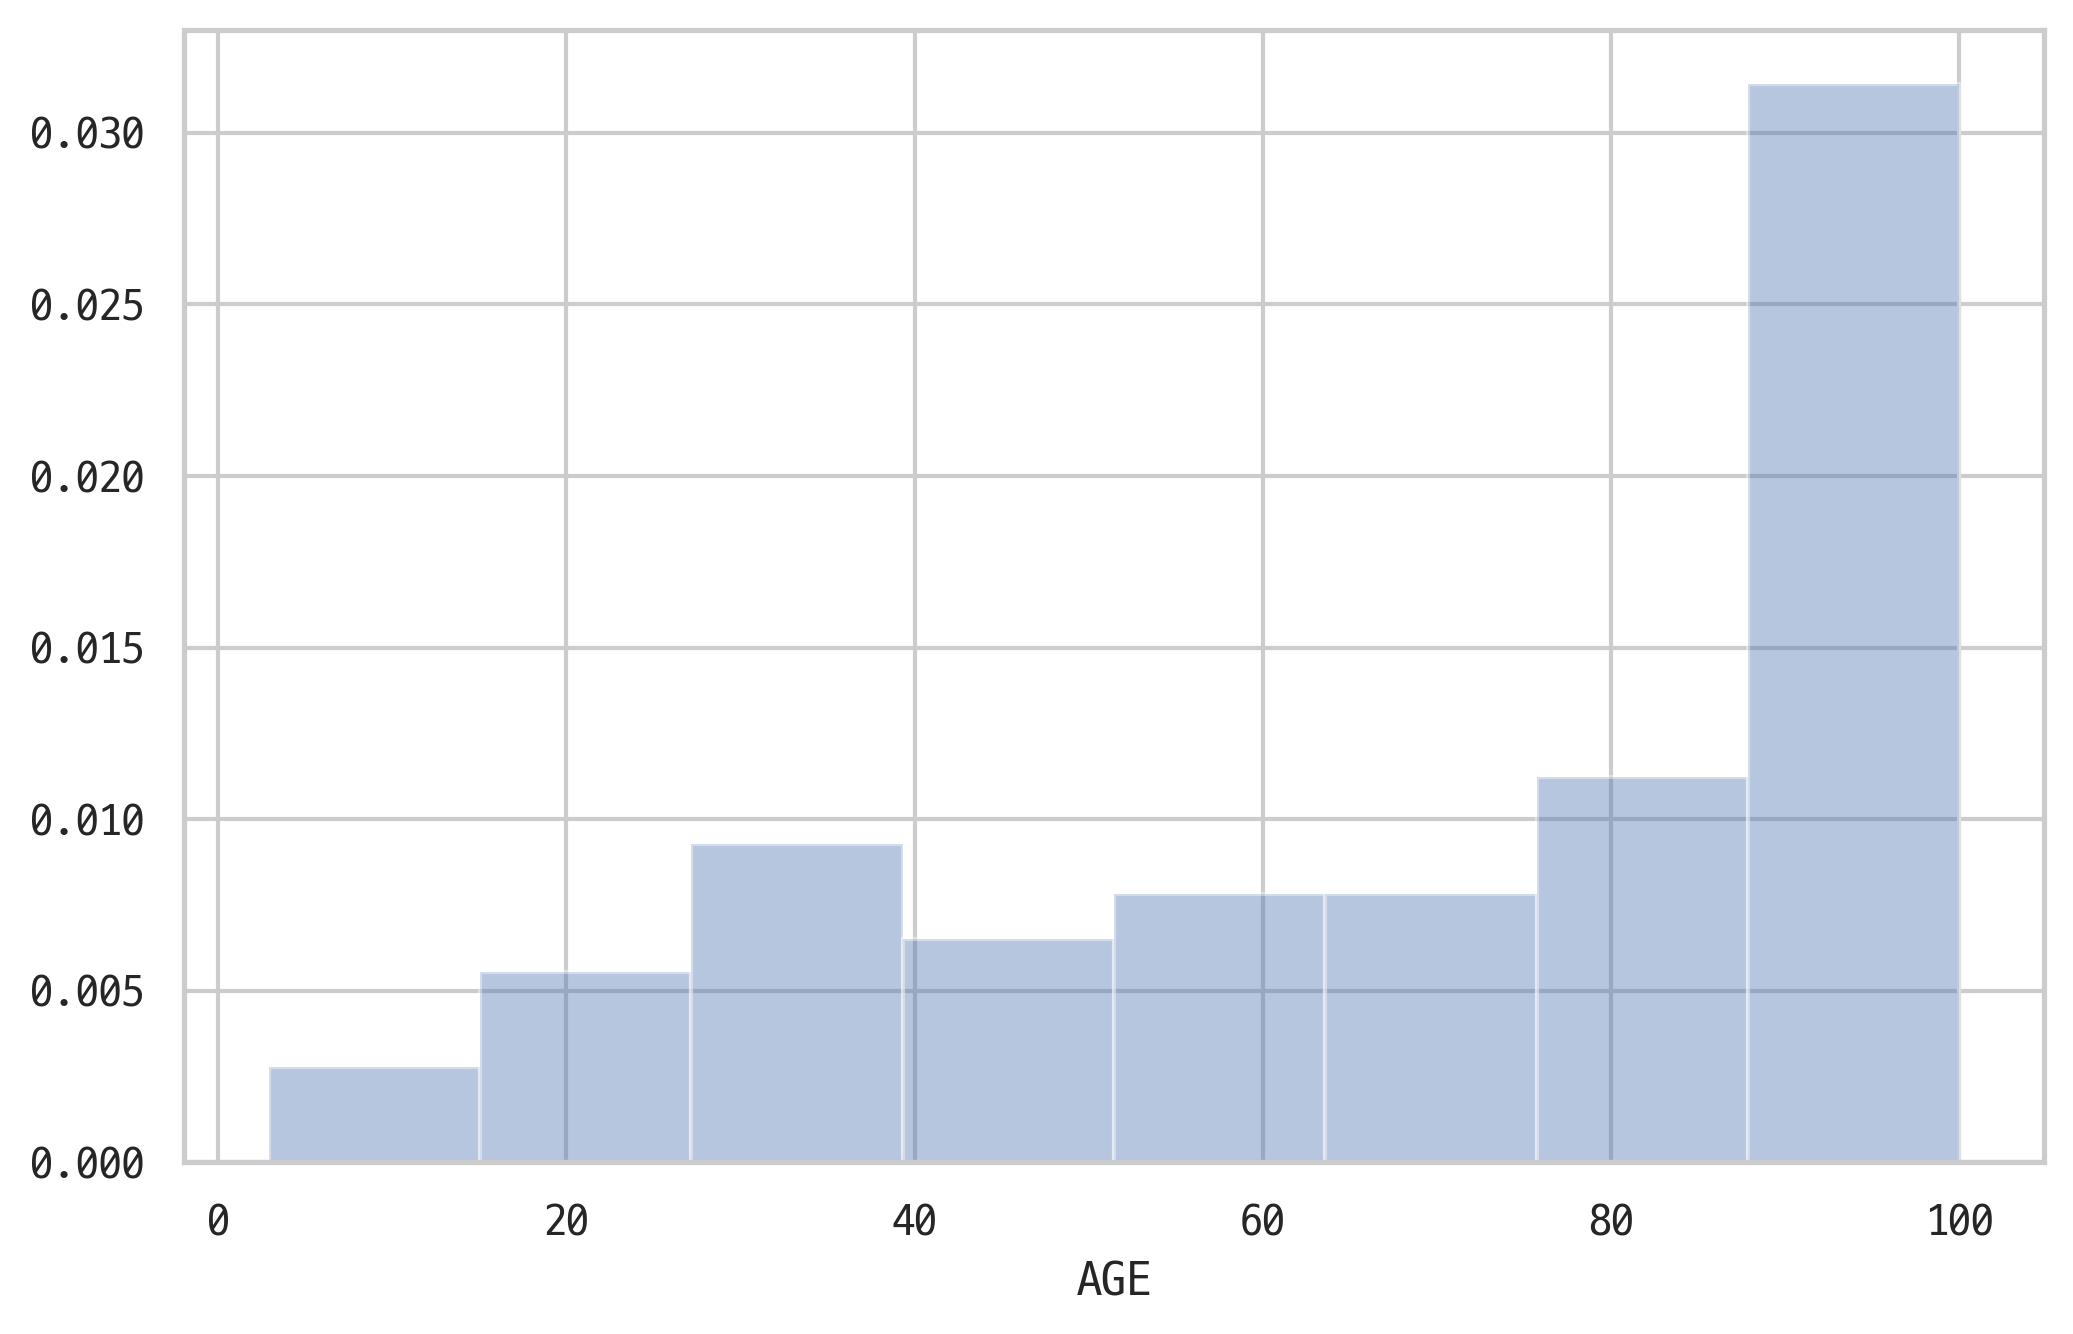

In [38]:
from sklearn.datasets import load_boston
boston = load_boston()
dfX = pd.DataFrame(boston.data, columns=boston.feature_names)
dfy = pd.DataFrame(boston.target, columns=["MEDV"])
df = pd.concat([dfX, dfy], axis=1)
 
sns.distplot(df.CRIM, kde=False, norm_hist=True, fit=sp.stats.lognorm) # CRIM
plt.show()
sns.distplot(df.ZN, kde=False, norm_hist=True) # ZN
plt.show()
sns.distplot(df.INDUS, kde=False, norm_hist=True) # ZN
plt.show()

sns.distplot(df.NOX, kde=False, norm_hist=True) # ZN
plt.show()
sns.distplot(df.RM, kde=False, norm_hist=True) # ZN
plt.show()
sns.distplot(df.AGE, kde=False, norm_hist=True) # ZN
plt.show()
